# Marketing A/B Testing

## Object
A marketing company ran a randomized A/B experiment to find out if showing advertisements leads to more customer conversions than displaying a Public Service Announcement (PSA). 

The aim is to see if the increase in conversion is statistically significant and if it comes from the advertising campaign rather than random chance.

## Hypothese 
H0:Pad ≤ Ppsa  
H1:Pad > Ppsa

Pad = Propotion of advertisment group   
Ppsa = Propotion of public service announcement group

	






## Exploratory Data Analysis(EDA)

In [ ]:
##Load the data set 
import pandas as pd
df = pd.read_csv("data/marketing_AB.csv")

In [7]:
##Clean the dataset 
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Rename columns
df.columns = (
    df.columns
      .str.lower()
      .str.replace(" ", "_")
)

df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [8]:
#Dataset size 
print(df.shape)

(588101, 6)


In [9]:
#DataType 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        588101 non-null  int64 
 1   test_group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total_ads      588101 non-null  int64 
 4   most_ads_day   588101 non-null  object
 5   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [10]:
#Summery 
df.describe(include="all")

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
count,5.881010e+05,588101,588101,588101.000000,588101,588101.000000
unique,NaN,2,2,NaN,7,NaN
top,NaN,ad,False,NaN,Friday,NaN
freq,NaN,564577,573258,NaN,92608,NaN
mean,1.310692e+06,NaN,NaN,24.820876,NaN,14.469061
std,2.022260e+05,NaN,NaN,43.715181,NaN,4.834634
min,9.000000e+05,NaN,NaN,1.000000,NaN,0.000000
25%,1.143190e+06,NaN,NaN,4.000000,NaN,11.000000
50%,1.313725e+06,NaN,NaN,13.000000,NaN,14.000000
75%,1.484088e+06,NaN,NaN,27.000000,NaN,18.000000


In [11]:
#Calculate the Conversion Rate 
conversion_rate = (
    df.groupby("test_group")["converted"]
      .mean()
      .reset_index()
)

conversion_rate

,test_group,converted
0,ad,0.025547
1,psa,0.017854


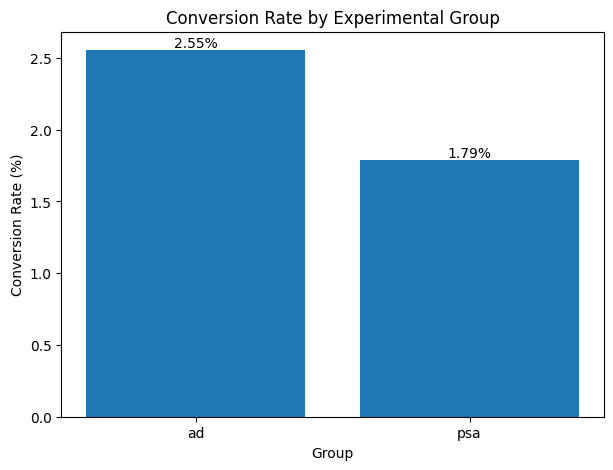

In [12]:
# Vizualization 
import matplotlib.pyplot as plt

conversion = (
    df.groupby("test_group")["converted"]
      .mean()
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    conversion.index,
    conversion.values*100
)

plt.ylabel("Conversion Rate (%)")
plt.xlabel("Group")
plt.title("Conversion Rate by Experimental Group")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()



The bar graph shows that the advertisement has a higher conversion rate than the public service announcement. However, this difference cannot be confirmed solely from the graph, as it may have occurred by chance. Therefore, a statistical test is required to determine whether the difference is significant.


**Difference between two propotion:**   
Pad - Ppsa = 0.025547 - 0.017854 = 0.007693   
**Pooled Propotion** = 14843 / 588101 = 0.02524   
**Standard Error(SE)** = 0.00103  

### Z test 
Z = (Pad - Ppsa)/SE = 0.007693 / 0.00103 = 7.468  
thresh hold value = 0.05  
so that Z critical value = 1.645 (this is one tail test)  
Z > Z critical   
So this Statistically Significant, We can reject null hypothesis  
This is mannualy z test calculation.   

Lets see how visually this 

Observed Lift (B - A): 0.0077
Calculated Z-statistic: 7.4689
One-tailed P-value: 0.0000


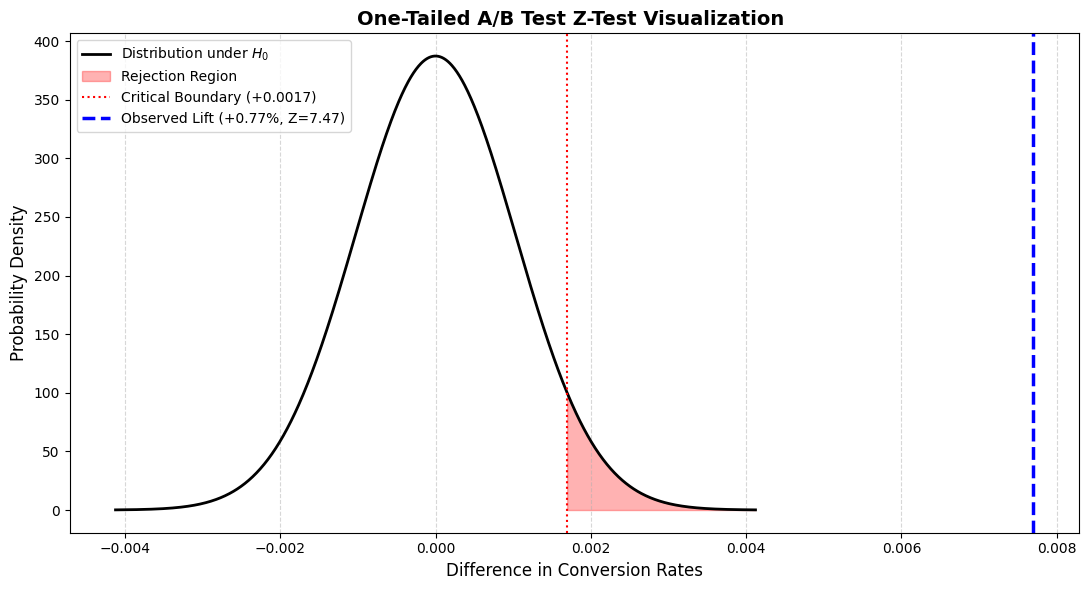

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Directly input your Proportions and Standard Error (SE)
Pad = 0.025547      # Conversion rate for advertisment
Ppsa = 0.017854     # Conversion rate for public service announcement
se_difference = 0.00103  # Standard Error of the difference

# 2. Compute the observed lift and calculated Z-statistic
observed_diff = Pad - Ppsa
z_stat = observed_diff / se_difference
p_value = 1 - norm.cdf(z_stat)  # One-tailed p-value calculation

print(f"Observed Lift (B - A): {observed_diff:.4f}")
print(f"Calculated Z-statistic: {z_stat:.4f}")
print(f"One-tailed P-value: {p_value:.4f}")

# 3. Set up visualization parameters (One-Tailed)
alpha = 0.05
z_critical = norm.ppf(1 - alpha)  # 1.645 boundary threshold
critical_diff_upper = z_critical * se_difference

# Generate X values centered at 0 (H0: no difference) using your SE
x = np.linspace(-4 * se_difference, 4 * se_difference, 1000)
y = norm.pdf(x, 0, se_difference)

# 4. Plot the distribution curve
plt.figure(figsize=(11, 6))
plt.plot(x, y, label='Distribution under $H_0$', color='black', lw=2)

# 5. Shade only the RIGHT rejection region
plt.fill_between(x, y, where=(x >= critical_diff_upper), color='red', alpha=0.3, label='Rejection Region')

# 6. Mark the critical boundary and your observed lift
plt.axvline(critical_diff_upper, color='red', linestyle=':', label=f'Critical Boundary (+{critical_diff_upper:.4f})')
plt.axvline(observed_diff, color='blue', linestyle='--', lw=2.5, 
            label=f'Observed Lift ({observed_diff*100:+.2f}%, Z={z_stat:.2f})')

# 7. Chart decorations
plt.title('One-Tailed A/B Test Z-Test Visualization ', fontsize=14, fontweight='bold')
plt.xlabel('Difference in Conversion Rates', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


This visualization shows that the observed **Z-statistic** falls in the tail of the **Z-distribution**, beyond the critical value. Therefore, the probability of observing such an extreme value under the null hypothesis is very small. Consequently, we reject the null hypothesis.


### Permutation Test


The two-proportion Z-test relies on the normal approximation derived from the Central Limit Theorem. Although this approximation is appropriate for large samples, it is useful to validate the conclusion using a distribution-free method.

A permutation test evaluates the null hypothesis by repeatedly shuffling the treatment labels while keeping the conversion outcomes fixed. If advertisements truly have no effect, the treatment labels (ad or psa) are exchangeable, and any observed difference in conversion rates should be explainable by random assignment.

The permutation distribution represents the differences in conversion rates that would be expected purely by chance under the null hypothesis.

In [14]:
# Conversion rates
ad_rate = df.loc[df["test_group"] == "ad", "converted"].mean()
psa_rate = df.loc[df["test_group"] == "psa", "converted"].mean()

# Observed statistic
observed_difference = ad_rate - psa_rate

print(observed_difference)

0.007692453192201517


This statistic will be compare against the permutation distributuion

In [15]:
#Build the null distribution

#import numpy library
import numpy as np

np.random.seed(42)

n_permutations = 10000

differences = []

conversion = df["converted"].to_numpy()
groups = df["test_group"].to_numpy()

for _ in range(n_permutations):

    shuffled_groups = np.random.permutation(groups)

    ad = conversion[shuffled_groups == "ad"]
    psa = conversion[shuffled_groups == "psa"]

    diff = ad.mean() - psa.mean()

    differences.append(diff)

differences = np.array(differences)

In [16]:
#Calculate the p value 
p_perm = np.mean(differences >= observed_difference)

print(p_perm)

0.0


This p value of observesd difference close to zero. Lets check critical value

In [17]:
critical_value = np.percentile(differences, 95)

print(critical_value)

0.001714516190127524


This is Critical value.  
Critical value > P value . So that this is statistically significant, Therefore we can reject the null hypothesis.  
Let see visualization 

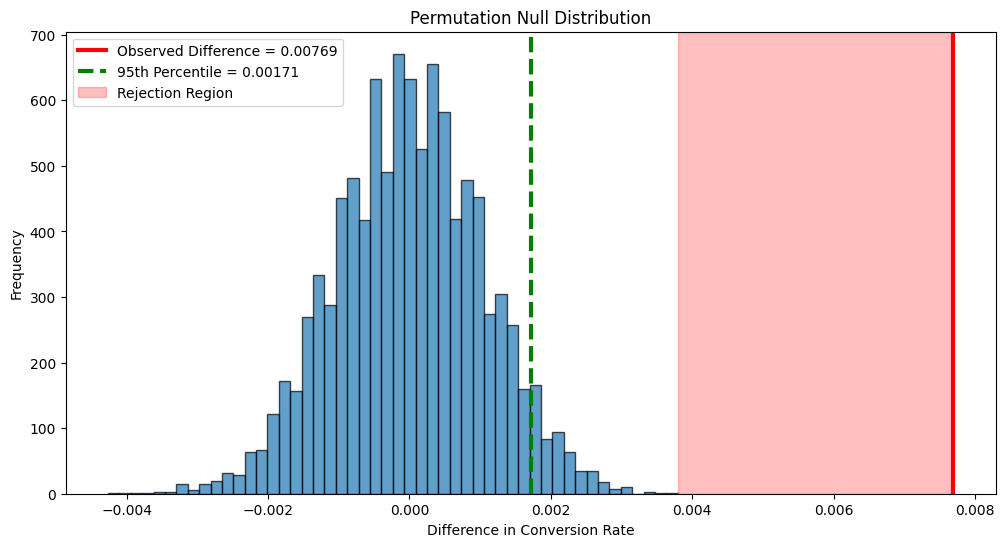

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.hist(
    differences,
    bins=50,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    observed_difference,
    color="red",
    linewidth=3,
    label=f"Observed Difference = {observed_difference:.5f}"
)

plt.axvline(
    critical_value,
    color="green",
    linestyle="--",
    linewidth=3,
    label=f"95th Percentile = {critical_value:.5f}"
)

plt.axvspan(
    observed_difference,
    differences.max(),
    alpha=0.25,
    color="red",
    label="Rejection Region"
)

plt.xlabel("Difference in Conversion Rate")
plt.ylabel("Frequency")
plt.title("Permutation Null Distribution")
plt.legend()

plt.show()

The permutation distribution is centered near zero, which is expected under the null hypothesis that advertisements have no effect on conversion. The observed difference in conversion rates lies far to the right of the permutation distribution and exceeds the 95th percentile of the null distribution. The permutation p-value is effectively zero, indicating that such a large difference is extremely unlikely to occur by random assignment alone. Therefore, we reject the null hypothesis and conclude that the advertisement campaign significantly improves conversion rates.

### Compare the Two Methods

Both the two-proportion Z-test and the permutation test led to the same conclusion: the advertisement campaign significantly increased conversion rates. This agreement is expected because the dataset contains a very large number of observations. Under the Central Limit Theorem, the sampling distribution of the difference in proportions is well approximated by a normal distribution, making the Z-test appropriate. The permutation test, which does not rely on distributional assumptions, produced an almost identical result, providing additional confidence that the observed improvement is not due to random chance.

### Business Recommendation

The analysis provides strong statistical evidence that the advertisement campaign increased the conversion rate compared with the public service announcement. Both the two-proportion Z-test and the permutation test rejected the null hypothesis, indicating that the observed improvement is unlikely to be explained by random variation alone. The campaign increased the conversion rate by approximately 0.77 percentage points, corresponding to a 43% relative improvement over the control group. While this suggests that the advertisement is more effective than the PSA in generating conversions, additional business metrics such as campaign cost, revenue per conversion, and return on investment should be evaluated before making long-term budget decisions.